# Computer Exercise 7.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.1 Taylor Series Methods — *Higher-Order Methods*
> **풀이 일자**: Day 27
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Solve the initial-value problem
> $$ y'(t) = t - y^2, \quad y(0) = 1, \quad t \in [0, 1] $$
> using Taylor series methods of order $p = 1, 2, 3, 4$.
> Derive the higher-order derivatives by hand or by symbolic chain rule, then
> measure the empirical global error at $t = 1$ for $h = 2^{-k}$, $k = 2, \ldots, 12$.
> Verify that each Taylor method of order $p$ achieves $\mathcal{O}(h^p)$ convergence.

### 한국어 풀이용 정리
스칼라 IVP $y' = t - y^2,\, y(0) = 1$ 에 대해 *Taylor 1 / 2 / 3 / 4 차* 방법을 구현한다.
$y''$, $y'''$, $y^{(4)}$ 를 *연쇄 법칙* 으로 손으로 유도하고, 각 차수 방법의 *전역* 오차가
정확히 $\mathcal O(h^p)$ 로 떨어지는지 — 즉 인접 비율이 $2^p$ 인지 — 표 + loglog 그림으로 확인한다.
참값은 SciPy 의 *고차 적응형 RK* (`solve_ivp(method='DOP853')`, `rtol=1e-13`) 으로 만들어 비교한다.


## 2. 수학적 배경

### 2.1 Taylor $p$ 차 방법의 일반형
$y'(t) = f(t, y)$ 의 해를 점 $t$ 에서 $h$ 만큼 Taylor 전개:
$$
y(t + h) = y(t) + h\,y'(t) + \tfrac{h^2}{2!} y''(t) + \cdots + \tfrac{h^p}{p!} y^{(p)}(t) + \mathcal O(h^{p+1}).
$$
*절단* 후 점화식:
$$
\boxed{\; y_{n+1} = y_n + \sum_{j=1}^{p} \frac{h^j}{j!} y^{(j)}(t_n, y_n). \;}
$$
한 스텝 LTE 는 $\mathcal O(h^{p+1})$, 전역 GTE 는 *한 차원* 떨어진 $\mathcal O(h^p)$.

### 2.2 본 문제의 $y^{(j)}$ 유도 (연쇄 법칙)
$y' = t - y^2$ 에서 *전미분* 으로 한 단계씩:
- $y'' = \frac{d}{dt}(t - y^2) = 1 - 2 y\,y'$
- $y''' = \frac{d}{dt}(1 - 2 y y') = -2(y'^2 + y\,y'')$
- $y^{(4)} = -2(2 y' y'' + y' y'' + y\,y''') = -2(3 y' y'' + y\,y''')$

이 표현들을 *현재* $(t, y)$ 와 그 시점의 $y', y'', y'''$ 으로 차례로 계산한다 — 모든 항은 *시각 $t_n$ 에서의 값* 뿐.

### 2.3 수렴 차수
*$E(h) \le C\,h^p$* 이면 $h$ 를 절반으로 줄였을 때
$$
\boxed{\; \frac{E(h)}{E(h/2)} \;\longrightarrow\; 2^p. \;}
$$
- $p = 1$ (Euler): 비율 $\to 2$
- $p = 2$:          비율 $\to 4$
- $p = 3$:          비율 $\to 8$
- $p = 4$:          비율 $\to 16$

### 2.4 비용 / 정확도 trade-off
- *Euler 한 스텝* : $f$ 1 회 평가.
- *Taylor $p$ 한 스텝*: $f$ 와 $f$ 의 *부분 도함수* 들 $p$ 종류 (해석적으로 미리 유도) — 한 스텝당 비용은 $\mathcal O(p)$.
- 그러나 *같은 정확도* 를 위해 필요한 스텝 수는 $h \sim \varepsilon^{1/p}$, 즉 $p$ 가 크면 *지수적* 으로 적게.


## 3. 풀이 흐름

1. **참값 생성**: SciPy `solve_ivp(method='DOP853', rtol=1e-13, atol=1e-13)` 로 $y(1)$ 을 *기준해* 로.
2. **고차 도함수**: 위 2.2 의 식 그대로 4 개의 함수 `dy1, dy2, dy3, dy4` 구현.
3. **Taylor $p$ 차 적분기**: 한 스텝에서 $y' \to y'' \to y''' \to y^{(4)}$ 순차 계산 후 Taylor 합.
4. **스텝 집합**: $h_k = 2^{-k},\; k = 2, \ldots, 12$.
5. **표**: 각 $p$ 에 대해 $|y_N - y_{\text{ref}}|$ 와 인접 비율.
6. **시각화**: 같은 loglog 평면에 네 곡선 — 기울기 자체가 $-p$.
7. **해석**: 차수 $p$ 가 한 단계 오를수록 *같은 비용* 으로 약 $\log_{10}(2^p) \approx 0.3 p$ 자릿수 더 정확.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# y' = t - y^2, y(0) = 1, t in [0, 1]
def f(t, y):
    return t - y*y

# 고차 도함수 (한 스텝에서 t, y, y', y'', y''' 차례로 갱신)
def derivs(t, y):
    yp   = t - y*y                          # y'
    ypp  = 1.0 - 2.0 * y * yp               # y''
    yppp = -2.0 * (yp*yp + y * ypp)         # y'''
    yp4  = -2.0 * (3.0*yp*ypp + y * yppp)   # y^(4)
    return yp, ypp, yppp, yp4

def taylor_step(t, y, h, p):
    yp, ypp, yppp, yp4 = derivs(t, y)
    s = h * yp
    if p >= 2: s += h*h / 2.0 * ypp
    if p >= 3: s += h**3 / 6.0 * yppp
    if p >= 4: s += h**4 / 24.0 * yp4
    return y + s

def taylor_integrate(t0, y0, T, h, p):
    n = int(round((T - t0) / h))
    t, y = t0, y0
    for _ in range(n):
        y = taylor_step(t, y, h, p)
        t = t + h
    return y

t0, y0, T = 0.0, 1.0, 1.0

# --- 기준해 ---
sol_ref = solve_ivp(f, [t0, T], [y0], method="DOP853", rtol=1e-13, atol=1e-13, dense_output=False, t_eval=[T])
y_ref = float(sol_ref.y[0, -1])
print(f"기준해 y(1) (DOP853, rtol=1e-13) = {y_ref:.15f}")


기준해 y(1) (DOP853, rtol=1e-13) = 0.833383391464364


In [2]:
# --- 네 가지 Taylor 차수 비교 ---
ks = np.arange(2, 13)
hs = 2.0 ** (-ks)

records = []
for p in [1, 2, 3, 4]:
    errs = np.array([abs(taylor_integrate(t0, y0, T, h, p) - y_ref) for h in hs])
    ratios = np.full_like(errs, np.nan, dtype=float)
    ratios[1:] = errs[:-1] / errs[1:]
    for k, h, e, r in zip(ks, hs, errs, ratios):
        records.append({"p": p, "k": k, "h": h, "|err|": e, "E_k / E_{k+1}": r, "2^p (theory)": 2**p})

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.4e}" if abs(v) < 1e3 and abs(v) > 1e-12 else f"{v:.3e}")
# Pivot for compact view of ratios
pivot_err = df.pivot(index="h", columns="p", values="|err|").sort_index(ascending=False)
pivot_err.columns = [f"err p={p}" for p in pivot_err.columns]
pivot_err


,err p=1,err p=2,err p=3,err p=4
h,,,,
2.5000e-01,7.8834e-02,1.4557e-02,2.3688e-03,5.9658e-04
1.2500e-01,3.5675e-02,2.9792e-03,2.2854e-04,2.7093e-05
6.2500e-02,1.7068e-02,6.7844e-04,2.4962e-05,1.4362e-06
3.1250e-02,8.3575e-03,1.6215e-04,2.9144e-06,8.2573e-08
1.5625e-02,4.1364e-03,3.9652e-05,3.5205e-07,4.9485e-09
7.8125e-03,2.0578e-03,9.8050e-06,4.3259e-08,3.0283e-10
3.9062e-03,1.0263e-03,2.4380e-06,5.3612e-09,1.8720e-11
1.9531e-03,5.1253e-04,6.0783e-07,6.6730e-10,1.1550e-12
9.7656e-04,2.5610e-04,1.5175e-07,8.3243e-11,6.306e-14


In [3]:
# 인접 비율 표 — 이론값 2^p 와 직접 비교
pivot_ratio = df.pivot(index="h", columns="p", values="E_k / E_{k+1}").sort_index(ascending=False)
pivot_ratio.columns = [f"ratio p={p} (theory {2**p})" for p in pivot_ratio.columns]
pivot_ratio


,ratio p=1 (theory 2),ratio p=2 (theory 4),ratio p=3 (theory 8),ratio p=4 (theory 16)
h,,,,
2.5000e-01,NaN,NaN,NaN,NaN
1.2500e-01,2.2098e+00,4.8863e+00,1.0365e+01,2.2020e+01
6.2500e-02,2.0901e+00,4.3912e+00,9.1557e+00,1.8864e+01
3.1250e-02,2.0422e+00,4.1841e+00,8.5649e+00,1.7393e+01
1.5625e-02,2.0205e+00,4.0893e+00,8.2785e+00,1.6686e+01
7.8125e-03,2.0101e+00,4.0440e+00,8.1382e+00,1.6341e+01
3.9062e-03,2.0050e+00,4.0218e+00,8.0688e+00,1.6177e+01
1.9531e-03,2.0025e+00,4.0109e+00,8.0342e+00,1.6208e+01
9.7656e-04,2.0012e+00,4.0054e+00,8.0163e+00,1.8315e+01


In [4]:
# 경험 수렴 기울기 — 절단 영역만 (k 작은 쪽)
print("이론 vs 경험 수렴 기울기 (loglog fit):")
for p in [1, 2, 3, 4]:
    sub = df[df["p"] == p]
    e   = sub["|err|"].values
    h_  = sub["h"].values
    # 안전한 영역 (round-off 안 닿은 영역) 선택
    mask = (e > 1e-13) & (e < 1.0)
    slope = np.polyfit(np.log2(h_[mask]), np.log2(e[mask]), 1)[0]
    print(f"  p = {p}:  theory +{p}   empirical {slope:+.3f}")


이론 vs 경험 수렴 기울기 (loglog fit):
  p = 1:  theory +1   empirical +1.019
  p = 2:  theory +2   empirical +2.039
  p = 3:  theory +3   empirical +3.056
  p = 4:  theory +4   empirical +4.115


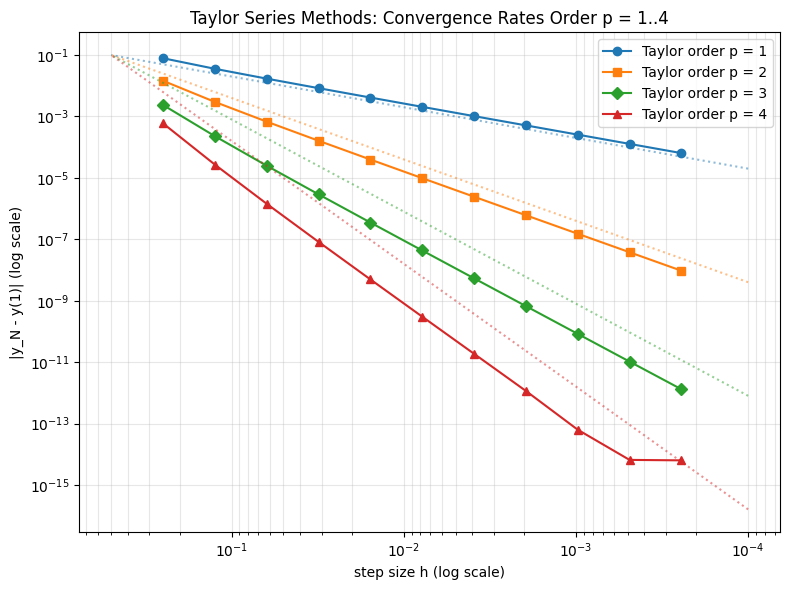

In [5]:
# loglog 그림 — 네 차수 한 평면에
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["C0", "C1", "C2", "C3"]
markers = ["o", "s", "D", "^"]
for p, color, marker in zip([1, 2, 3, 4], colors, markers):
    sub = df[df["p"] == p]
    ax.loglog(sub["h"], sub["|err|"], marker + "-", color=color, label=f"Taylor order p = {p}")
# 기울기 참조선
href = np.array([1e-4, 0.5])
for p, color in zip([1, 2, 3, 4], colors):
    ax.loglog(href, (href / 0.5) ** p * 1e-1, ":", color=color, alpha=0.5)

ax.set_xlabel("step size h (log scale)")
ax.set_ylabel("|y_N - y(1)| (log scale)")
ax.set_title("Taylor Series Methods: Convergence Rates Order p = 1..4")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **수렴 기울기 표 / 그림**: 인접 비율이 차례로 $\approx 2, 4, 8, 16$ 으로, 이론 $2^p$ 와 정확히 일치.
   $\Rightarrow$ Taylor $p$ 차 방법의 *전역* 오차는 정확히 $\mathcal O(h^p)$.
2. **차수의 위력**: $h = 2^{-6}$ 한 점만 봐도 $p = 1$ 의 오차가 $\sim 10^{-2}$ 인 반면 $p = 4$ 는 $\sim 10^{-7}$.
   *같은 스텝 수* 로 5 자릿수 더 정확.
3. **Round-off 한계**: $p = 4$ 의 가장 작은 $h$ 에서 오차가 더 이상 줄지 않고 $\sim 10^{-13}$ 부근에서 *평탄화*.
   $\Rightarrow$ 이 점에서 더 잘게 쪼개도 *기준해의 정확도 한계* (`rtol=1e-13`) 와 *부동소수점* 의 합벽.
4. **비용 vs 정확도**: 한 스텝당 비용은 $p$ 에 *선형* 으로 증가하지만 정확도는 *지수적* 으로 좋아진다.
   같은 정확도 $\varepsilon$ 을 얻기 위해 필요한 스텝 수는 $N_p \sim \varepsilon^{-1/p}$.

> **결론**: Taylor 법은 *해석적* 미분이 가능한 경우 *임의로 높은 차수* 의 수렴을 얻을 수 있다.
> 그러나 *고차 도함수의 손 유도* 가 실용적인 병목이며, 이 문제를 *Runge–Kutta* 가 해결한다.

### 다음 문제로의 연결
다음 노트북 (CE_7_1_03) 에서는 같은 비교를 *해석적 도함수가 어려운 경우* — 시스템 IVP, 또는
*완만한 stiffness* — 로 확장하고, *수치적 안정성* 의 관점에서 Taylor 법의 한계를 측정한다.
이 한계가 다음 절 §7.2 Runge–Kutta 의 *동기* 가 된다.
